# Classificatore Real+Augmented (`trad_aug`) — ResNet-50

Configurazione **trad_aug** (compito di Samuele). Serve come **braccio "augmentation tradizionale"
del confronto di sostenibilità (D3)**: NON gareggia sulle metriche del classificatore a 3 config
(D2), che qui restano solo come contesto. Modello **ResNet-50 riciclato dal baseline del collega**
(non ricostruito), addestrato sui dati Real+Augmented.

- **TRAIN** = originali reali a 2 classi (`data/processed/train/{0,1}`) **+** positivi augmentati
  in modo tradizionale (`data/real_augmented/`, solo `_label1`, suffisso `_augN`).
- **VAL / TEST** = solo reali held-out (`data/processed/{val,test}`), mai augmentati.

Valutazione **sul TEST** (soglia di Youden scelta sul **VAL**). Sostenibilità di training e
inferenza misurata con `eco_tracker` (servizio standalone). MammoDiffusion è READ-ONLY: i dati si
leggono da lì, non si modifica nulla.

> **Esecuzione**: WSL2 + GPU (RTX 3050 Ti, 4 GB). Vedi guida di setup. Lanciare Jupyter dalla
> cartella `valutazione/` (così `eco_tracker.py` è importabile). IMG_SIZE/BATCH ridotti per la VRAM.

#### Setup percorsi e `eco_tracker`

In [1]:
import os, sys

# Rileva Colab vs locale/WSL e imposta il percorso base di MammoDiffusion (READ-ONLY)
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("Ambiente locale/WSL rilevato.")
    # Da WSL il disco C: di Windows e' sotto /mnt/c. I dati stanno in MammoDiffusion (read-only).
    BASE_PATH = '/mnt/c/Users/samto/Desktop/MammoDiffusion/'
    # Da Windows nativo invece: BASE_PATH = r'C:/Users/samto/Desktop/MammoDiffusion/'
print("Percorso base:", BASE_PATH)

# eco_tracker.py (servizio standalone) sta in valutazione/. Lancia Jupyter da quella cartella,
# oppure scommenta e aggiusta la riga seguente:
sys.path.insert(0, '/mnt/c/Users/samto/Desktop/valutazione')  # trova il vero eco_tracker anche da MammoDiffusion/notebooks/
try:
    from eco_tracker import measure_sustainability
    ECO_OK = True
except Exception as e:
    print("[eco_tracker non trovato:", e, "] -> sostenibilita' (D3) saltata.")
    ECO_OK = False
    import contextlib
    class _DummyEco:
        metrics = None
    @contextlib.contextmanager
    def measure_sustainability(label="run", sample_interval=0.5):
        yield _DummyEco()

Ambiente locale/WSL rilevato.
Percorso base: /mnt/c/Users/samto/Desktop/MammoDiffusion/


#### Import

In [2]:
import re
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score,
                             classification_report, precision_score,
                             recall_score, f1_score, accuracy_score)

2026-06-16 16:38:42.157763: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-16 16:38:42.373723: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-16 16:38:45.007098: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### GPU (memory growth per i 4 GB della RTX 3050 Ti)

In [3]:
# Con 4 GB di VRAM il memory growth e' essenziale (altrimenti TF pre-alloca tutta la memoria).
gpus = tf.config.list_physical_devices('GPU')
print("GPU viste da TF:", gpus)
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("set_memory_growth:", e)
if not gpus:
    print("ATTENZIONE: nessuna GPU vista da TF -> stai girando su CPU.")

# Opzionale: mixed precision dimezza la VRAM. Se la attivi, tieni l'ultimo layer in float32
# (Dense(1, activation='sigmoid', dtype='float32')) per stabilita' con la focal loss.
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy('mixed_float16')

GPU viste da TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Configurazione

In [4]:
SEED = 42
ARCH = "ResNet-50"
# Dimensioni adattate ai 4 GB della RTX 3050 Ti (il collega usa 512x512 / batch 8 su Colab T4).
# Aumentale se hai piu' VRAM (o giri su Colab). 512x512 NON entra in 4 GB.
IMG_SIZE = (256, 256)
BATCH_SIZE = 4
UNFREEZE_FROM = "conv5_block3_1_conv"   # layer da cui sbloccare il backbone in Fase 2
BACKBONE_NAME = "resnet50"     # nome del layer backbone (per eventuale Grad-CAM)
CONFIG = "trad_aug"

IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

# L'augmentation tradizionale e' gia' materializzata in real_augmented -> niente aug on-the-fly di default
AUG_ONLINE = False

OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'exp_trad_aug_resnet50')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

keras.utils.set_random_seed(SEED)
print("ARCH:", ARCH, "| IMG_SIZE:", IMG_SIZE, "| BATCH:", BATCH_SIZE, "| OUTPUT_DIR:", OUTPUT_DIR)

ARCH: ResNet-50 | IMG_SIZE: (256, 256) | BATCH: 4 | OUTPUT_DIR: /mnt/c/Users/samto/Desktop/MammoDiffusion/experiments/exp_trad_aug_resnet50


I0000 00:00:1781620727.472156   15347 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


#### Preparazione dati `trad_aug`

TRAIN = reali a 2 classi (`train/{0,1}`) + positivi augmentati (`real_augmented`, label nel nome
file). VAL/TEST = solo reali held-out. Caricamento da cartelle (gli augmentati non sono nei CSV).

In [5]:
DIR_TRAIN = os.path.join(BASE_PATH, 'data', 'processed', 'train')   # sottocartelle 0/ (Sano) e 1/ (Malato)
DIR_VAL   = os.path.join(BASE_PATH, 'data', 'processed', 'val')
DIR_TEST  = os.path.join(BASE_PATH, 'data', 'processed', 'test')
DIR_AUG   = os.path.join(BASE_PATH, 'data', 'real_augmented')        # augmentati tradizionali, solo positivi

_LABEL_RE = re.compile(r"_label([01])")

def carica_da_cartelle_classi(base_dir, classi=("0", "1")):
    # Originali: la label e' il nome della sottocartella (0=Sano, 1=Malato)
    paths, labels = [], []
    for c in classi:
        for p in sorted(Path(base_dir).joinpath(c).glob("*.png")):
            paths.append(str(p)); labels.append(int(c))
    return np.array(paths), np.array(labels, dtype=np.int32)

def carica_da_nome(dirpath):
    # Augmentati: la label e' nel nome file (_label0 / _label1)
    paths, labels = [], []
    for p in sorted(Path(dirpath).glob("*.png")):
        m = _LABEL_RE.search(p.name)
        if m is None:
            continue
        paths.append(str(p)); labels.append(int(m.group(1)))
    return np.array(paths), np.array(labels, dtype=np.int32)

# TRAIN = reali (2 classi) + augmentati positivi ; VAL/TEST = solo reali held-out
real_tr_p, real_tr_y = carica_da_cartelle_classi(DIR_TRAIN)
aug_p, aug_y = carica_da_nome(DIR_AUG)
train_p = np.concatenate([real_tr_p, aug_p])
train_y = np.concatenate([real_tr_y, aug_y])
val_p, val_y = carica_da_cartelle_classi(DIR_VAL)
test_p, test_y = carica_da_cartelle_classi(DIR_TEST)

def _comp(nome, y):
    print("%-6s tot=%5d | Sano(0)=%5d | Malato(1)=%5d" % (nome, len(y), int((y==0).sum()), int((y==1).sum())))
print("[trad_aug] reali train=%d + augmentati positivi=%d" % (len(real_tr_y), len(aug_y)))
_comp("TRAIN", train_y); _comp("VAL", val_y); _comp("TEST", test_y)

def _preprocess(path, label, augment):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    if augment:
        img = img + tf.random.normal(tf.shape(img), mean=0.0, stddev=0.05)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, tf.cast(label, tf.float32)

def make_ds(p, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((p, y))
    if shuffle:
        ds = ds.shuffle(len(p), seed=SEED)
    ds = ds.map(lambda a, b: _preprocess(a, b, augment), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_p, train_y, augment=AUG_ONLINE, shuffle=True)
val_ds   = make_ds(val_p, val_y, augment=False, shuffle=False)
test_ds  = make_ds(test_p, test_y, augment=False, shuffle=False)

# Pesi delle classi dal train trad_aug (anche con gli augmentati i positivi restano meno numerosi)
_classes = np.unique(train_y)
_w = compute_class_weight("balanced", classes=_classes, y=train_y)
class_weight_dict = dict(zip(_classes.astype(int), _w))
print("Class weights:", class_weight_dict)

[trad_aug] reali train=2041 + augmentati positivi=0
TRAIN  tot= 2041 | Sano(0)= 1701 | Malato(1)=  340
VAL    tot=  437 | Sano(0)=  364 | Malato(1)=   73
TEST   tot=  438 | Sano(0)=  365 | Malato(1)=   73
Class weights: {np.int64(0): np.float64(0.5999412110523221), np.int64(1): np.float64(3.001470588235294)}


#### Architettura ResNet-50 (riciclata dal baseline del collega)

Backbone pre-addestrato congelato + testina custom (GAP -> Dense256 L2 -> BN -> LeakyReLU ->
Dropout -> sigmoid). Identica al baseline; cambia solo il backbone.

In [6]:
def build_model():
    base_model = keras.applications.ResNet50(
        weights='imagenet', include_top=False, input_shape=IMG_SIZE + (3,)
    )
    base_model.trainable = False   # Fase 1: backbone congelato
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = base_model(inputs, training=False)   # training=False fondamentale per la BatchNorm del backbone
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs), base_model

def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss_fn

model, base_model = build_model()
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,537 (91.99 MB)

 Trainable params: 525,313 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

#### Training a 2 fasi (misurato con `eco_tracker`)

In [7]:
# Fase 1: addestra solo la testina (backbone congelato), binary crossentropy
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
)
cb1 = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, mode='max'),
    keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_fase1_best.keras'),
                                    monitor='val_auc', save_best_only=True, mode='max'),
]

# Tutto il training (Fase 1 + Fase 2) misurato insieme per la D3
with measure_sustainability(label="training_trad_aug_resnet50") as eco:
    history_phase1 = model.fit(train_ds, epochs=25, validation_data=val_ds,
                               class_weight=class_weight_dict, callbacks=cb1)

    # Fase 2: fine-tuning dal layer UNFREEZE_FROM in poi, focal loss, LR molto basso
    base_model.trainable = True
    set_trainable = False
    for layer in base_model.layers:
        if layer.name == UNFREEZE_FROM:
            set_trainable = True
        layer.trainable = set_trainable
    print("Layer addestrabili:", len(model.trainable_variables))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss=focal_loss(gamma=2.0, alpha=0.75),
        metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
    )
    cb2 = [
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, min_delta=1e-3,
                                      restore_best_weights=True, mode='max'),
        keras.callbacks.ModelCheckpoint(os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_final_best.keras'),
                                        monitor='val_auc', save_best_only=True, mode='max'),
        keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max', min_lr=1e-7),
    ]
    history_phase2 = model.fit(train_ds, epochs=30, validation_data=val_ds,
                               class_weight=class_weight_dict, callbacks=cb2)

eco_train = eco.metrics
print("Training completato. eco_train:", eco_train)

[codecarbon WARNING @ 16:39:21] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 1/25


2026-06-16 16:39:45.150276: I external/local_xla/xla/service/service.cc:163] XLA service 0x75c8840146e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-16 16:39:45.150376: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-06-16 16:39:46.237499: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-16 16:39:51.964272: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
I0000 00:00:1781620808.689422   15443 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


511/511 ━━━━━━━━━━━━━━━━━━━━ 99s 116ms/step - accuracy: 0.5365 - auc: 0.5244 - loss: 0.9084 - recall: 0.5088 - val_accuracy: 0.5584 - val_auc: 0.6085 - val_loss: 0.7346 - val_recall: 0.5342
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.5561 - auc: 0.5723 - loss: 0.7994 - recall: 0.5647 - val_accuracy: 0.2792 - val_auc: 0.5314 - val_loss: 1.2544 - val_recall: 0.9178
Epoch 3/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.5419 - auc: 0.5584 - loss: 0.7907 - recall: 0.5794 - val_accuracy: 0.4439 - val_auc: 0.5928 - val_loss: 0.8783 - val_recall: 0.7397
Epoch 4/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - accuracy: 0.5585 - auc: 0.5864 - loss: 0.7499 - recall: 0.5706 - val_accuracy: 0.3913 - val_auc: 0.6123 - val_loss: 0.8818 - val_recall: 0.8219
Epoch 5/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.5659 - auc: 0.6006 - loss: 0.7437 - recall: 0.5588 - val_accuracy: 0.3318 - val_auc: 0.6159 - val_loss: 0.9189 - val_recall: 0.8904
Epoch 6/25

2026-06-16 16:53:24.645228: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-06-16 16:53:25.088066: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


511/511 ━━━━━━━━━━━━━━━━━━━━ 85s 120ms/step - accuracy: 0.6355 - auc: 0.6367 - loss: 0.1846 - recall: 0.5265 - val_accuracy: 0.6728 - val_auc: 0.6078 - val_loss: 0.1710 - val_recall: 0.4110 - learning_rate: 1.0000e-05
Epoch 2/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.6874 - auc: 0.6496 - loss: 0.1705 - recall: 0.4765 - val_accuracy: 0.6773 - val_auc: 0.6239 - val_loss: 0.1691 - val_recall: 0.3288 - learning_rate: 1.0000e-05
Epoch 3/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7178 - auc: 0.6791 - loss: 0.1669 - recall: 0.4912 - val_accuracy: 0.7071 - val_auc: 0.6079 - val_loss: 0.1693 - val_recall: 0.3562 - learning_rate: 1.0000e-05
Epoch 4/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.7491 - auc: 0.7387 - loss: 0.1529 - recall: 0.5353 - val_accuracy: 0.6819 - val_auc: 0.6266 - val_loss: 0.1665 - val_recall: 0.3836 - learning_rate: 1.0000e-05
Epoch 5/30
511/511 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.7658 - auc: 0.7658 - loss: 0.1

#### Curve di training

Grafico salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/experiments/exp_trad_aug_resnet50/figures/training_history_fase1_resnet50.png


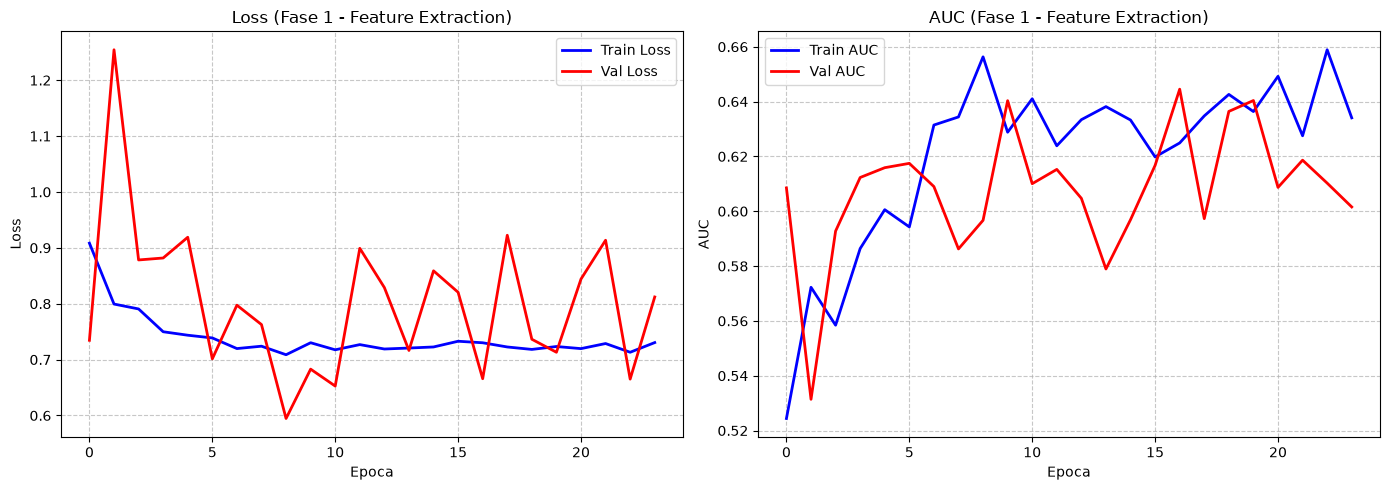

Grafico salvato in: /mnt/c/Users/samto/Desktop/MammoDiffusion/experiments/exp_trad_aug_resnet50/figures/training_history_fase2_resnet50.png


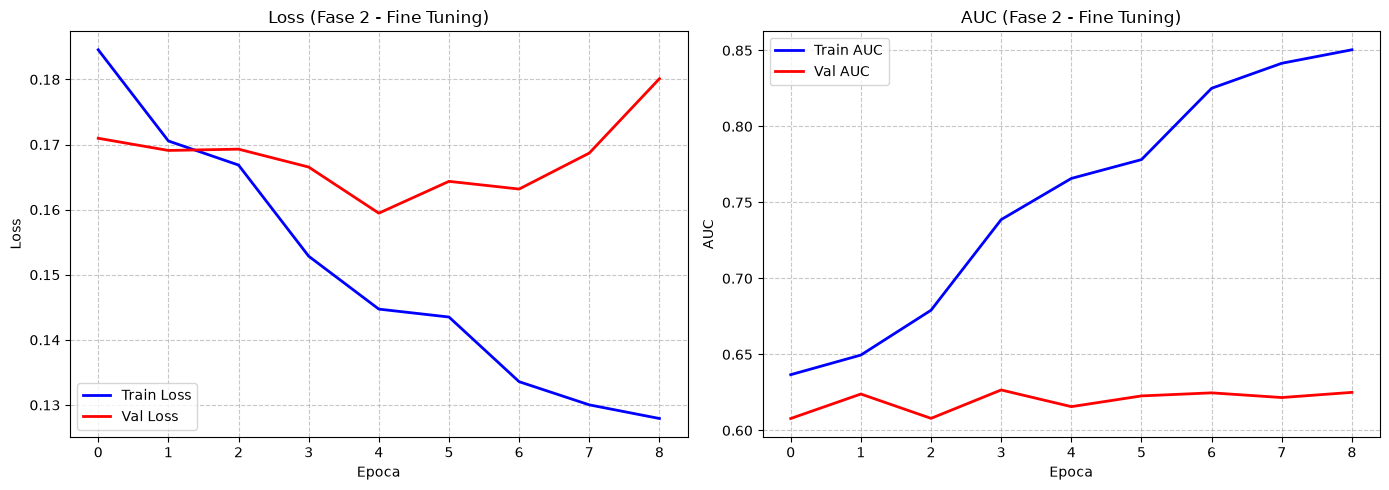

In [8]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title('Loss ' + title_suffix); ax1.set_xlabel('Epoca'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.7)
    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title('AUC ' + title_suffix); ax2.set_xlabel('Epoca'); ax2.set_ylabel('AUC')
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print("Grafico salvato in:", save_path)
    plt.show()

plot_training_history(history_phase1, "(Fase 1 - Feature Extraction)",
                      os.path.join(FIGURES_DIR, 'training_history_fase1_resnet50.png'))
plot_training_history(history_phase2, "(Fase 2 - Fine Tuning)",
                      os.path.join(FIGURES_DIR, 'training_history_fase2_resnet50.png'))

#### Valutazione sul TEST (soglia di Youden scelta sul VAL)

Metriche del classificatore come **contesto** (non sei nella gara D2 a 3 config). La soglia
(Youden's J) si sceglie sul **VAL** e si applica al **TEST**, per evitare bias ottimistico.

2026-06-16 16:59:56.269168: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Soglia di Youden (da VAL): 0.4062


2026-06-16 17:00:34.959058: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


AUC (test): 0.5867
              precision    recall  f1-score   support

        Sano       0.87      0.49      0.63       365
      Malato       0.20      0.62      0.30        73

    accuracy                           0.51       438
   macro avg       0.53      0.55      0.46       438
weighted avg       0.75      0.51      0.57       438

Metriche salvate in test_metrics_resnet50.json


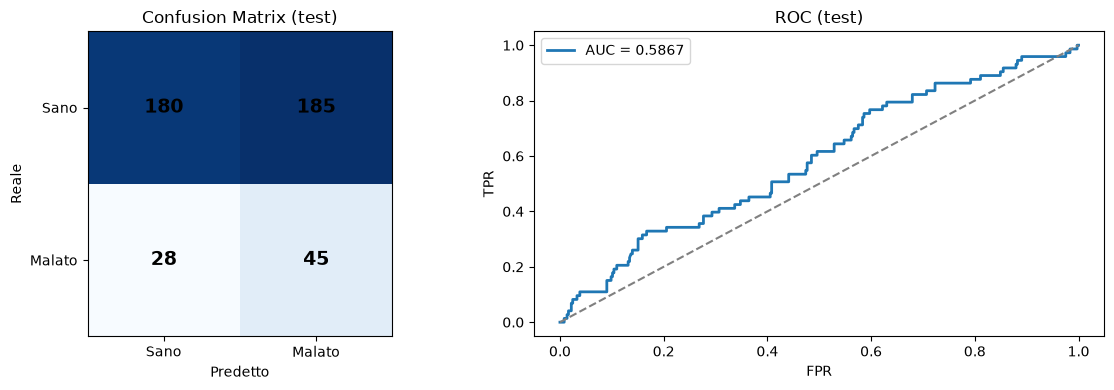

In [9]:
# Carica il miglior modello (Fase 2)
best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'trad_aug_resnet50_final_best.keras'),
    custom_objects={'loss_fn': focal_loss(gamma=2.0, alpha=0.75)}
)

def predici(ds):
    yt, yp = [], []
    for imgs, labels in ds:
        yp.extend(best_model.predict(imgs, verbose=0).flatten())
        yt.extend(labels.numpy())
    return np.array(yt), np.array(yp)

# 1) Soglia di Youden dal VAL
val_true, val_prob = predici(val_ds)
fpr_v, tpr_v, thr_v = roc_curve(val_true, val_prob)
best_threshold = float(thr_v[np.argmax(tpr_v - fpr_v)])
print("Soglia di Youden (da VAL):", round(best_threshold, 4))

# 2) Inferenza sul TEST (misurata per la D3) + applica la soglia del val
with measure_sustainability(label="inference_trad_aug_resnet50") as eco:
    test_true, test_prob = predici(test_ds)
eco_inf = eco.metrics
test_pred = (test_prob >= best_threshold).astype(int)

# 3) Metriche sul TEST (contesto)
auc = roc_auc_score(test_true, test_prob)
report = classification_report(test_true, test_pred, target_names=['Sano', 'Malato'])
print("AUC (test):", round(float(auc), 4))
print(report)

metrics_dict = {
    'arch': ARCH, 'config': CONFIG, 'split': 'test',
    'threshold_youden_from_val': round(best_threshold, 4),
    'roc_auc': round(float(auc), 4),
    'accuracy': round(float(accuracy_score(test_true, test_pred)), 4),
    'precision_malato': round(float(precision_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'recall_malato': round(float(recall_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'f1_malato': round(float(f1_score(test_true, test_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report,
}
with open(os.path.join(OUTPUT_DIR, 'test_metrics_resnet50.json'), 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print("Metriche salvate in test_metrics_resnet50.json")

# 4) Figura: confusion matrix + ROC (test)
cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Sano', 'Malato']); ax[0].set_yticklabels(['Sano', 'Malato'])
ax[0].set_xlabel('Predetto'); ax[0].set_ylabel('Reale'); ax[0].set_title('Confusion Matrix (test)')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
fpr_t, tpr_t, _ = roc_curve(test_true, test_prob)
ax[1].plot(fpr_t, tpr_t, lw=2, label='AUC = %.4f' % auc)
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC (test)'); ax[1].legend()
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'test_confusion_roc_resnet50.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Valutazione bilanciata a bootstrap (il test e' ~5:1)

Il test e' sbilanciato (365 Sani / 73 Malati). Tieni tutti i positivi, campiona pari negativi,
calcola le metriche su N round e media (media +/- std): evita l'accuracy gonfiata dallo sbilanciamento.

Accuracy   0.5705 +/- 0.0199
Precision  0.5654 +/- 0.0205
Recall     0.6164 +/- 0.0000
F1         0.5896 +/- 0.0112
ROC_AUC    0.5999 +/- 0.0277


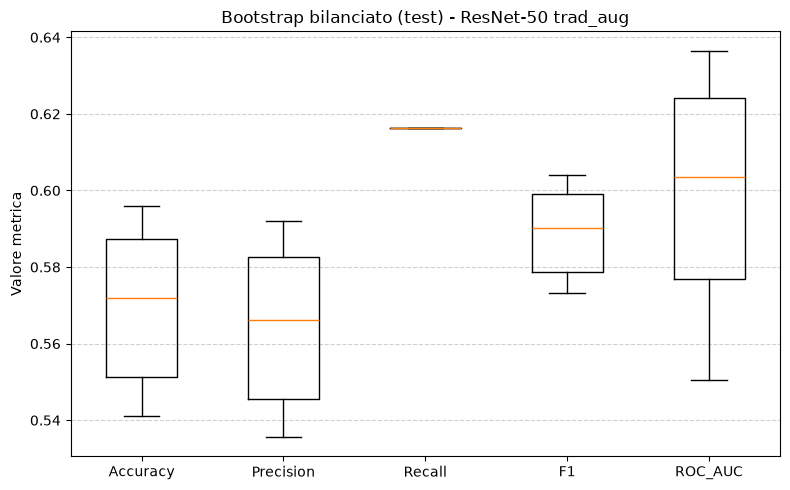

In [10]:
def bootstrap_bilanciato(y_true, y_prob, threshold, n_rounds=10, seed=SEED):
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n = min(len(pos_idx), len(neg_idx))
    out = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'ROC_AUC': []}
    for _ in range(n_rounds):
        sel_neg = rng.choice(neg_idx, size=n, replace=False)
        idx = np.concatenate([pos_idx, sel_neg])
        yt, yp = y_true[idx], y_prob[idx]
        pred = (yp >= threshold).astype(int)
        out['Accuracy'].append(accuracy_score(yt, pred))
        out['Precision'].append(precision_score(yt, pred, pos_label=1, zero_division=0))
        out['Recall'].append(recall_score(yt, pred, pos_label=1, zero_division=0))
        out['F1'].append(f1_score(yt, pred, pos_label=1, zero_division=0))
        out['ROC_AUC'].append(roc_auc_score(yt, yp))
    for k, v in out.items():
        print("%-10s %.4f +/- %.4f" % (k, np.mean(v), np.std(v)))
    return out

boot = bootstrap_bilanciato(test_true, test_prob, best_threshold, n_rounds=10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(list(boot.values()))
ax.set_xticklabels(list(boot.keys()))
ax.set_title('Bootstrap bilanciato (test) - ResNet-50 trad_aug')
ax.set_ylabel('Valore metrica'); ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'bootstrap_resnet50.png'), dpi=150, bbox_inches='tight')
plt.show()

#### Sostenibilità (D3) — deliverable principale di questa config

In [11]:
# Riepilogo D3: costo di training + inferenza dell'approccio "augmentation tradizionale".
# NB (WSL): codecarbon legge la potenza GPU via NVML, ma la potenza CPU (Intel RAPL) di solito
# NON e' esposta in WSL -> il contributo CPU e' stimato. Dichiararlo nel report.
if ECO_OK and eco_train is not None and eco_inf is not None:
    eco_summary = {'arch': ARCH, 'config': CONFIG,
                   'training': eco_train.to_dict(), 'inference': eco_inf.to_dict()}
    print("TRAINING :", eco_train)
    print("INFERENCE:", eco_inf)
    with open(os.path.join(OUTPUT_DIR, 'eco_resnet50.json'), 'w') as f:
        json.dump(eco_summary, f, indent=2, ensure_ascii=False)
    print("Eco salvato in eco_resnet50.json")
else:
    print("Sostenibilita' non misurata (eco_tracker non disponibile in questo ambiente).")

TRAINING : [training_trad_aug_resnet50] Tempo: 1179.94s | RAM picco: 2516.8 MB | Energia: 0.010345 kWh | CO2: 0.003421 kg
INFERENCE: [inference_trad_aug_resnet50] Tempo: 33.81s | RAM picco: 2527.3 MB | Energia: 0.000238 kWh | CO2: 0.000079 kg
Eco salvato in eco_resnet50.json
